In [ ]:
# Regresion Logística, Ingeniería de Características y Pipeline

!pip install -q kagglehub
!pip install -q imbalanced-learn

# Para la descarga y manipulación general de datasets
import kagglehub
import pandas as pd
import numpy as np
import os
import joblib # Para guardar y cargar modelos/pipelines


# Librerías de Scikit-learn para preprocesamiento y modelado
from sklearn.model_selection import train_test_split # Para dividir datos en entrenamiento y prueba
from sklearn.impute import SimpleImputer             # Para manejar valores nulos
from sklearn.model_selection import GridSearchCV



from sklearn.compose import ColumnTransformer     # Aplicación de transformaciones a diferentes columnas
from sklearn.pipeline import Pipeline             # Para Encadenar pasos de preprocesamiento y modelado
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer  # Para codificación categórica y escalado numérico
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    precision_recall_curve, accuracy_score
)

# Librerías para visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns


# Librerías de imbalanced-learn para manejar desbalance de clases
from imblearn.over_sampling import SMOTE             # Para generar datos sintéticos en clases minoritarias
from imblearn.pipeline import Pipeline as ImbPipeline # Pipeline compatible con imbalanced-learn
from imblearn.over_sampling import RandomOverSampler # Para manejar desbalance de clases

print("Librerías de visualización importadas correctamente.")



Librerías de visualización importadas correctamente.


In [ ]:
# 1) Descarga + Carga de dataset (robusto)

import kagglehub

# Descargar dataset
path = kagglehub.dataset_download("radheshyamkollipara/bank-customer-churn")
print("Path:", path)

# Archivo principal
csv_path = os.path.join(path, "Customer-Churn-Records.csv")
df = pd.read_csv(csv_path)

print("Shape original:", df.shape)
df.head()

df = pd.read_csv(csv_path)

100%|██████████| 307k/307k [00:00<00:00, 15.4MB/s]

Extracting files...
Path: /root/.cache/kagglehub/datasets/radheshyamkollipara/bank-customer-churn/versions/1
Shape original: (10000, 18)


### Descripción de las Variables del DataFrame

A continuación, se presenta una descripción de cada columna (variable) en el DataFrame `df`:

*   **`RowNumber`**: Número de fila, un identificador único para cada registro en el conjunto de datos.
*   **`CustomerId`**: Identificador único de cada cliente del banco.
*   **`Surname`**: Apellido del cliente.
*   **`CreditScore`**: Puntuación de crédito del cliente, que indica su solvencia financiera.
*   **`Geography`**: País de residencia del cliente (por ejemplo, Francia, España, Alemania).
*   **`Gender`**: Género del cliente (masculino o femenino).
*   **`Age`**: Edad del cliente.
*   **`Tenure`**: Número de años que el cliente ha estado en el banco.
*   **`Balance`**: Saldo de la cuenta del cliente.
*   **`NumOfProducts`**: Número de productos bancarios que el cliente utiliza (por ejemplo, cuentas, tarjetas de crédito).
*   **`HasCrCard`**: Indica si el cliente posee una tarjeta de crédito (1 si tiene, 0 si no tiene).
*   **`IsActiveMember`**: Indica si el cliente es un miembro activo del banco (1 si es activo, 0 si no lo es).
*   **`EstimatedSalary`**: Salario estimado del cliente.
*   **`Exited`**: Indica si el cliente ha abandonado el banco (1 si ha abandonado, 0 si no).
*   **`Complain`**: Indica si el cliente ha presentado una queja (1 si ha quejado, 0 si no).
*   **`Satisfaction Score`**: Puntuación de satisfacción del cliente (generalmente de 1 a 5).
*   **`Card Type`**: Tipo de tarjeta que posee el cliente (por ejemplo, DIAMOND, GOLD).
*   **`Point Earned`**: Puntos ganados por el cliente.

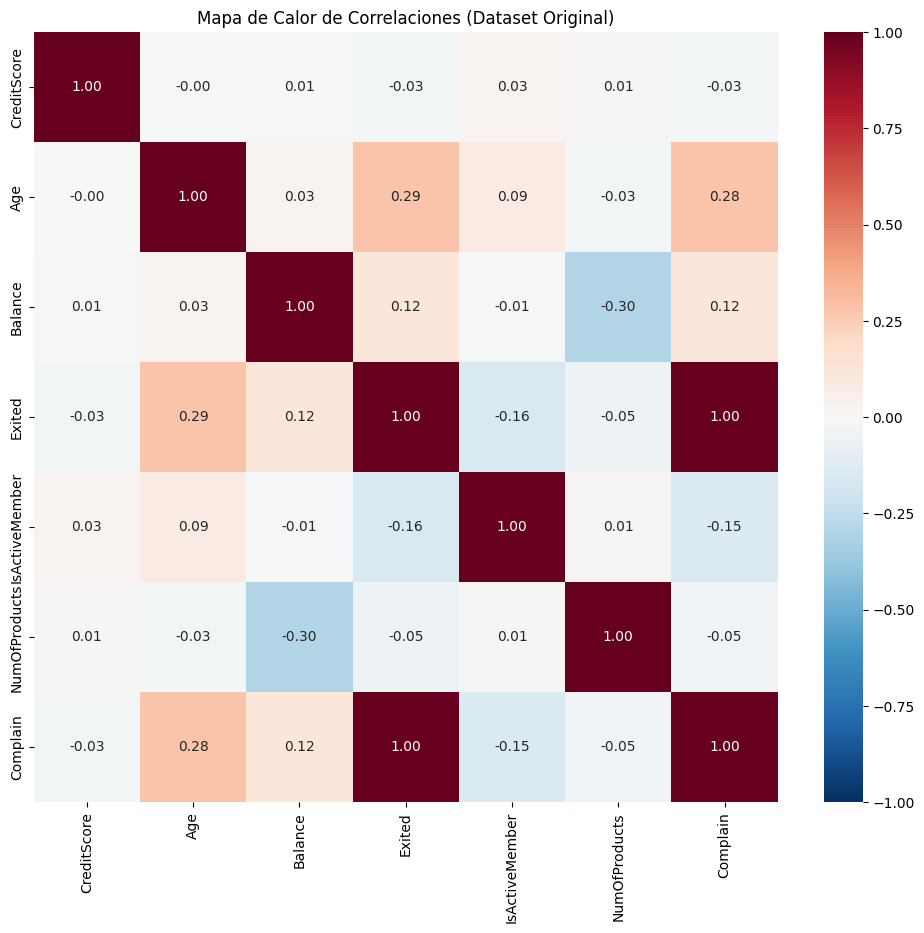

In [ ]:
# 1.1) EDA

import matplotlib.pyplot as plt
import seaborn as sns

# Análisis de Correlación General

# Definimos las columnas para el análisis de correlación (nombres originales)
cols_eda = [
    'CreditScore', 'Age', 'Balance',
    'Exited', 'IsActiveMember', 'NumOfProducts', 'Complain'
]

# 1. Mapa de Calor de Correlaciones Completo
plt.figure(figsize=(12, 10))
corr_matrix = df[cols_eda].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', fmt=".2f", vmin=-1, vmax=1)
plt.title('Mapa de Calor de Correlaciones (Dataset Original)')
plt.show()


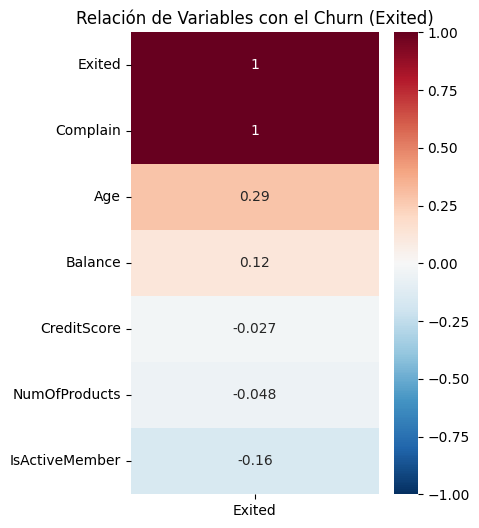

Distribución de Exited según Complain:
Exited            0          1
Complain                      
0         99.949723   0.050277
1          0.489237  99.510763


In [ ]:
# 1.2. Correlación específica con la variable Target (Exited)
plt.figure(figsize=(4, 6))
matriz_target = df[cols_eda].corr()[['Exited']].sort_values(by='Exited', ascending=False)

sns.heatmap(matriz_target, annot=True, cmap='RdBu_r', vmin=-1, vmax=1)
plt.title('Relación de Variables con el Churn (Exited)')
plt.show()

# 3. Análisis específico de la variable Complain
# Podemos ver
print("Distribución de Exited según Complain:")
print(pd.crosstab(df['Complain'], df['Exited'], normalize='index') * 100)

Data Leakage

Importante destacar que la variable Complain la eliminamos ya que nos genera Fuga de Datos.

Esta fuga hace que un modelo predictivo parezca preciso hasta que se implementa en su caso de uso; en ese caso, arroja resultados inexactos, lo que conduce a una mala toma de decisiones y a información errónea.

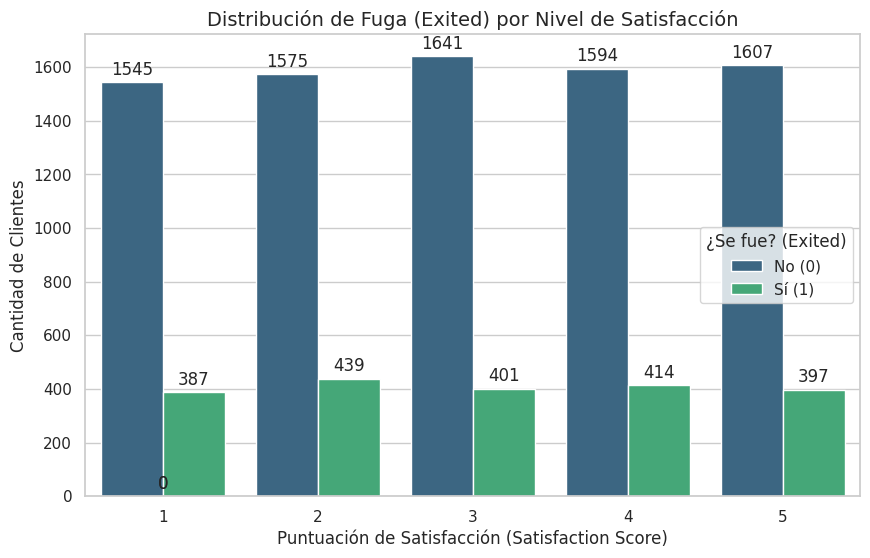

In [ ]:
# 1.4 Variable Satisfaction Score

import seaborn as sns
import matplotlib.pyplot as plt

# Configurar el estilo
sns.set_theme(style="whitegrid")

# Crear el gráfico
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='Satisfaction Score', hue='Exited', data=df, palette='viridis')

# Añadir títulos y etiquetas
plt.title('Distribución de Fuga (Exited) por Nivel de Satisfacción', fontsize=14)
plt.xlabel('Puntuación de Satisfacción (Satisfaction Score)', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)
plt.legend(title='¿Se fue? (Exited)', labels=['No (0)', 'Sí (1)'])

# Mostrar porcentajes sobre las barras (opcional pero muy útil)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')

plt.show()

 La Variable Satisfaction Score se procede a eliminar debido a su bajo poder discriminatorio.

Crosstab de Geography y Gender con respecto a Exited:

Exited                   0         1
Geography Gender                    
France    Female  0.796550  0.203450
          Male    0.872503  0.127497
Germany   Female  0.624476  0.375524
          Male    0.721884  0.278116
Spain     Female  0.787879  0.212121
          Male    0.868876  0.131124


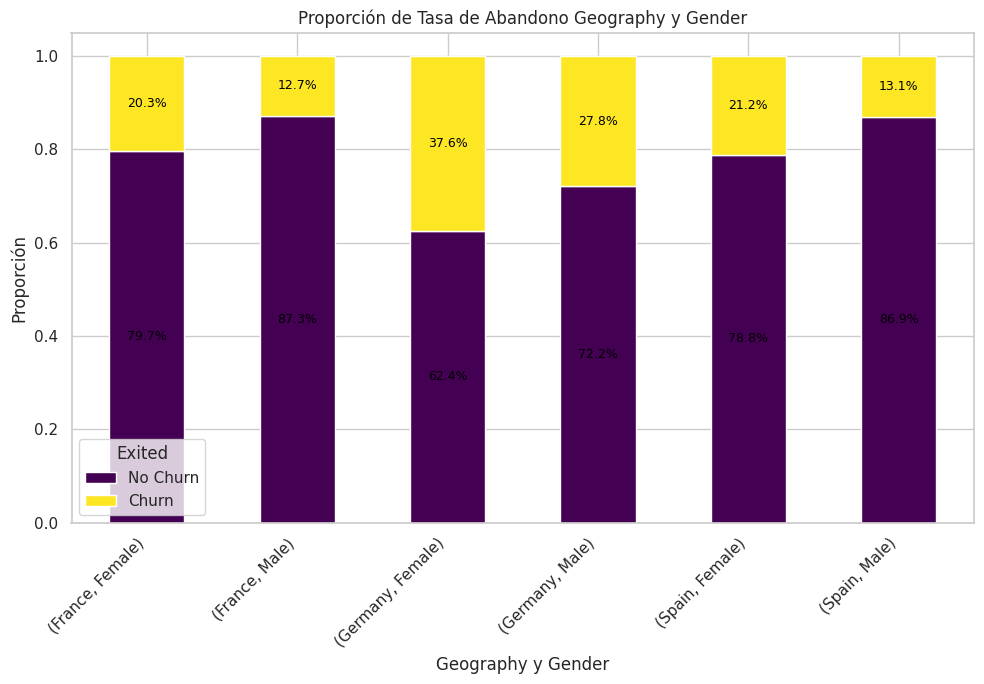

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1.3 Análisis Bivariado.

# 1.3.1 Defininiendo la lista de características categóricas a analizar
CAT_FEATURES_BIVARIATE_CAT = ['Geography', 'Gender']
TARGET = 'Exited'

# 1.3.2. Variables categóricas  Geografía vs. Género: Analizaremos cómo su combinación afecta la Variable Objetivo

# 1.3.3 Crear una tabla cruzada entre las dos características categóricas y el objetivo
crosstab_df = pd.crosstab(index=[df[CAT_FEATURES_BIVARIATE_CAT[0]], df[CAT_FEATURES_BIVARIATE_CAT[1]]], columns=df[TARGET], normalize='index')

print(f"Crosstab de {CAT_FEATURES_BIVARIATE_CAT[0]} y {CAT_FEATURES_BIVARIATE_CAT[1]} con respecto a {TARGET}:\n")
print(crosstab_df)

# 1.3.4 Plotting the stacked bar plot
fig, ax = plt.subplots(figsize=(10, 7))
crosstab_df.plot(kind='bar', stacked=True, cmap='viridis', ax=ax)

plt.title(f'Proporción de Tasa de Abandono {CAT_FEATURES_BIVARIATE_CAT[0]} y {CAT_FEATURES_BIVARIATE_CAT[1]}')
plt.xlabel(f'{CAT_FEATURES_BIVARIATE_CAT[0]} y {CAT_FEATURES_BIVARIATE_CAT[1]}')
plt.ylabel('Proporción')
plt.legend(title=TARGET, labels=['No Churn', 'Churn'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Add labels to the bars
for container in ax.containers:
    for rect in container:
        height = rect.get_height()
        if height > 0:  # Only label non-zero height bars
            ax.text(rect.get_x() + rect.get_width() / 2,  # X-position of the label
                    rect.get_y() + height / 2,             # Y-position of the label (center of the bar segment)
                    f'{height:.1%}',                       # Label text (formatted as percentage)
                    ha='center', va='center', color='black', fontsize=9)

plt.show()

In [ ]:
# 2) Limpieza y Normalización
# -----------------------------
cols_drop = ["RowNumber", "CustomerId", "Surname"]
df = df.drop(columns=[c for c in cols_drop if c in df.columns], errors="ignore")

df = df.rename(columns={
    "Satisfaction Score": "SatisfactionScore",
    "Card Type": "CardType",
    "Point Earned": "PointEarned",

})

#  2.1 Establecemos un TARGET

TARGET = "Exited"
if TARGET not in df.columns:
    raise ValueError(f"No existe la columna target '{TARGET}'. Columnas: {list(df.columns)}")

In [ ]:
# 3) Definición de Caracteristicas
#
# -----------------------------
NUM_FEATURES = ["Age", "CreditScore", "Balance", "NumOfProducts"]
CAT_FEATURES = ["Geography", "Gender"]
BIN_FEATURES = ["IsActiveMember"]


expected = NUM_FEATURES + CAT_FEATURES + BIN_FEATURES + [TARGET]
missing = [c for c in expected if c not in df.columns]
if missing:
    raise ValueError(f"Faltan columnas requeridas: {missing}")

X = df[NUM_FEATURES + CAT_FEATURES + BIN_FEATURES].copy()
y = df[TARGET].astype(int)

In [ ]:
def to_int_01(X):
    X = pd.DataFrame(X).copy()
    for col in X.columns:
        # Convertir explícitamente booleanos a int
        if X[col].dtype == bool:
            X[col] = X[col].astype(int)
        # Intentar convertir otros tipos a numérico. Los errores se convertirán en NaN.
        else:
            # Usar errors='coerce' para manejar no-numéricos y luego mapear True/False si son objetos
            temp_col = pd.to_numeric(X[col], errors="coerce")
            if temp_col.isna().all() and X[col].dtype == object: # Si todo es NaN y es objeto, intentar mapeo
                X[col] = X[col].map({"True": 1, "False": 0, True: 1, False: 0})
            else:
                X[col] = temp_col

    return X.values

bool_to_int = FunctionTransformer(to_int_01, feature_names_out="one-to-one")

num_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

bin_pipe = Pipeline(steps=[
    ("to_int", bool_to_int),
    ("imputer", SimpleImputer(strategy="most_frequent")),
    # binario queda 0/1 (sin escalado)
])


preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipe, NUM_FEATURES),
        ("cat", cat_pipe, CAT_FEATURES),
        ("bin", bin_pipe, BIN_FEATURES)

    ],
    remainder="drop",
    verbose_feature_names_out=False
)

In [ ]:
# 5.1) Pipeline alternativo con SMOTE para balanceo de clases (usar si el pipeline anterior está comentado)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Redefinimos el clasificador sin class_weight y con solver 'saga' para flexibilidad con param_grid
clf_smote = LogisticRegression(
    max_iter=2000,
    solver="saga", # 'saga' es compatible con todas las penalizaciones (l1, l2, elasticnet)
    # class_weight ya no es necesario cuando se usa SMOTE
)

smote = SMOTE(random_state=42)

pipe_smote = ImbPipeline(steps=[
    ("preprocess", preprocessor),
    ("smote", smote),
    ("model", clf_smote)
])

print("Pipeline 'pipe_smote' con SMOTE definido. Asegúrate de usar este pipeline para los pasos subsiguientes.")


Pipeline 'pipe_smote' con SMOTE definido. Asegúrate de usar este pipeline para los pasos subsiguientes.


In [ ]:
# -----------------------------
# 6) Train/Test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:

# 6.1) VIF (multicolinealidad) sobre TRAIN (post-feature engineering)
# Sólo Variables Numéricas

import numpy as np
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# a) Ajustar SOLO el preprocesador con TRAIN
#prep = pipe_smote.named_steps["preprocess"]
#prep.fit(X_train)

# b) Transformar TRAIN
#Xtr = prep.transform(X_train)

prep_vif = clone(pipe_smote.named_steps["preprocess"])
prep_vif.fit(X_train)
Xtr = prep_vif.transform(X_train)

# c) Pasar a denso si viene sparse
if hasattr(Xtr, "toarray"):
    Xtr = Xtr.toarray()

# d) Nombres de features post-transform
feature_names = prep_vif.get_feature_names_out()

Xtr_df = pd.DataFrame(Xtr, columns=feature_names)

# e) Quedarse con numéricas + ordinal (evita el ruido de los dummies one-hot)
keep_cols = [c for c in Xtr_df.columns if c in (NUM_FEATURES)]
X_vif = Xtr_df[keep_cols].copy()

# f) Calcular VIF
vif_df = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False)

vif_df



,feature,VIF
3,NumOfProducts,1.106179
2,Balance,1.105298
0,Age,1.001754
1,CreditScore,1.000392


En el pipeline que estamos utilizando, no hay un FeatureGenerator explícito como una etapa separada que cree nuevas columnas antes del preprocesador. En cambio, cualquier 'generación de características' (como la codificación one-hot para las variables categóricas) se realiza dentro del ColumnTransformer (que es el preprocessor).

El flujo es el siguiente:

Datos Originales (X): Contienen las características NUM_FEATURES, CAT_FEATURES y BIN_FEATURES.
preprocessor (ColumnTransformer): Toma estos datos originales y aplica las transformaciones definidas:
num_pipe para las características numéricas (imputación, escalado).
cat_pipe para las características categóricas (imputación, one-hot encoding, que crea nuevas columnas para las categorías).
bin_pipe para las características binarias (conversión a entero, imputación). El resultado de esta etapa son las características transformadas y listas para el modelo.
smote: Una vez que el preprocessor ha transformado las características (y potencialmente creado nuevas columnas como las dummies de one-hot encoding), el smote actúa sobre este conjunto de características transformadas (X_transformado) y el target (y).
SMOTE no crea nuevas columnas (características). Su función es generar nuevas filas (muestras sintéticas) para la clase minoritaria, basándose en las muestras existentes en el espacio de características ya transformado. Es decir, SMOTE balancea el dataset añadiendo más ejemplos al conjunto de datos, no modificando o creando variables predictoras adicionales.
En resumen, el preprocessor se encarga de que las características estén en el formato adecuado (incluyendo la creación de columnas de dummies), y luego SMOTE utiliza esas características ya preparadas para sintetizar nuevas observaciones.

In [ ]:
# 6.2) Agregamos Variables One-Hot

X_vif = Xtr_df.copy()

# (opcional) filtra columnas con varianza ~0 que puedan causar problemas numéricos
near_zero = X_vif.columns[(X_vif.var(axis=0) < 1e-12)]
X_vif = X_vif.drop(columns=near_zero)

vif_df = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False)

vif_df.head(30)

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,feature,VIF
4,Geography_France,inf
5,Geography_Germany,inf
8,Gender_Male,inf
6,Geography_Spain,inf
7,Gender_Female,inf
2,Balance,1.337617
3,NumOfProducts,1.125035
0,Age,1.012263
9,IsActiveMember,1.010014
1,CreditScore,1.001017


In [ ]:
# 6.3) VIF con one-hot K-1 (drop='first') – solo TRAIN

import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor


# 1) Reconstruir preprocessor SOLO para VIF
#    (idéntico al tuyo, pero con drop='first')


preprocessor_vif = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUM_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), CAT_FEATURES),
        ("bin", "passthrough", BIN_FEATURES),
    ],
    remainder="drop"
)

# 2) Fit SOLO con TRAIN

preprocessor_vif.fit(X_train)


# 3) Transformar TRAIN

Xtr = preprocessor_vif.transform(X_train)

# Si viene sparse → a denso
if hasattr(Xtr, "toarray"):
    Xtr = Xtr.toarray()


# 4) Nombres de features post-transform

feature_names = preprocessor_vif.get_feature_names_out()
Xtr_df = pd.DataFrame(Xtr, columns=feature_names)


# 5) (Opcional pero recomendado)
#     Eliminar columnas con varianza ~0

low_var_cols = Xtr_df.columns[Xtr_df.var(axis=0) < 1e-12]
Xtr_df = Xtr_df.drop(columns=low_var_cols)


# 6) Calcular VIF

vif_df = pd.DataFrame({
    "feature": Xtr_df.columns,
    "VIF": [
        variance_inflation_factor(Xtr_df.values, i)
        for i in range(Xtr_df.shape[1])
    ]
}).sort_values("VIF", ascending=False)

vif_df



,feature,VIF
6,cat__Gender_Male,1.618224
7,bin__IsActiveMember,1.592983
4,cat__Geography_Germany,1.450049
2,num__Balance,1.310613
5,cat__Geography_Spain,1.279614
3,num__NumOfProducts,1.123434
0,num__Age,1.009814
1,num__CreditScore,1.000974


Para evaluar multicolinealidad, se calculó el Factor de Inflación de Varianza (VIF) sobre la matriz de entrenamiento posterior al preprocesamiento.
Las variables categóricas fueron codificadas mediante one-hot encoding con K−1 dummies (drop='first')  Para evitar colinealidad perfecta (dummy trap).
Los resultados mostraron valores de VIF cercanos a 1, indicando ausencia de multicolinealidad relevante.”

El análisis de multicolinealidad mediante el Factor de Inflación de Varianza (VIF), aplicado sobre la matriz de entrenamiento posterior al preprocesamiento con codificación K−1 para variables categóricas, muestra valores de VIF cercanos a 1 para la mayoría de las variables.


# Tarea

Explicar el hiperparámetro `C` de `LogisticRegression`, su propósito como la inversa de la fuerza de regularización, y sugerir un rango de valores apropiados para la búsqueda de hiperparámetros.

## Explicar Hiperparámetro `C`

### Subtask:
Detallar el propósito del parámetro `C` en `LogisticRegression` (fuerza de regularización inversa) y sugerir un rango de valores para la búsqueda.

### Explicación del Hiperparámetro `C` en `LogisticRegression`

El parámetro `C` en `LogisticRegression` es un hiperparámetro crucial que **controla la fuerza de la regularización**. La regularización es una técnica utilizada para evitar el sobreajuste (overfitting) en los modelos, penalizando los coeficientes grandes del modelo.

Es importante entender que `C` es la **inversa de la fuerza de regularización**. Esto significa que:

*   **Valores más pequeños de `C`** implican una **regularización más fuerte**. Una regularización más fuerte reduce la complejidad del modelo y puede prevenir el sobreajuste, pero valores excesivamente pequeños pueden llevar a un subajuste (underfitting).
*   **Valores más grandes de `C`** implican una **regularización más débil**. Una regularización más débil permite que el modelo se ajuste más a los datos de entrenamiento, lo que puede ser útil si el modelo está subajustado, pero valores excesivamente grandes pueden resultar en sobreajuste.

### Rango de Valores Sugeridos para `C`

Al realizar una búsqueda de hiperparámetros (como `GridSearchCV` o `RandomizedSearchCV`), es común explorar `C` en una **escala logarítmica** debido a su impacto multiplicativo. Un rango de valores apropiado para `C` suele incluir potencias de 10. Algunos valores típicos a considerar para la búsqueda son:

*   `[0.001, 0.01, 0.1, 1, 10, 100, 1000]`

Este rango cubre desde una regularización muy fuerte (0.001) hasta una regularización muy débil (1000), permitiendo encontrar el equilibrio óptimo para el modelo.

## Explicar Hiperparámetro `penalty`

### Subtask:
Detallar el propósito del parámetro `penalty` (regularización L1, L2, Elastic-Net) y sugerir los tipos de penalización a probar.


El parámetro `penalty` en `LogisticRegression` de scikit-learn define el tipo de regularización a aplicar al modelo. La regularización es una técnica utilizada para evitar el sobreajuste (overfitting) y mejorar la generalización del modelo, añadiendo un término de penalización a la función de coste. Esto ayuda a reducir la complejidad del modelo y a gestionar la multicolinealidad.

### Tipos de Regularización:

1.  **`'l2'` (Ridge Regression o Tikhonov Regularization)**:
    *   **Propósito**: Añade una penalización proporcional al cuadrado de la magnitud de los coeficientes (`sum(coef**2)`). Esto anima a los coeficientes a ser pequeños, pero no necesariamente cero.
    *   **Efecto en los coeficientes**: Shrinks (reduce) los coeficientes de las características menos importantes hacia cero. Raramente los hace exactamente cero, lo que significa que todas las características tienden a permanecer en el modelo.
    *   **Uso**: Es la penalización por defecto y es muy efectiva para reducir la varianza del modelo, especialmente cuando hay muchas características correlacionadas.

2.  **`'l1'` (Lasso Regression)**:
    *   **Propósito**: Añade una penalización proporcional al valor absoluto de la magnitud de los coeficientes (`sum(|coef|)`).
    *   **Efecto en los coeficientes**: Tiene un efecto de selección de características (sparsity). Puede forzar los coeficientes de las características menos importantes a ser exactamente cero, eliminando efectivamente esas características del modelo. Esto resulta en un modelo más esparso y fácil de interpretar.
    *   **Uso**: Útil cuando se sospecha que muchas características son irrelevantes y se desea un modelo más interpretable o para situaciones con un alto número de características.

3.  **`'elasticnet'` (Elastic-Net Regularization)**:
    *   **Propósito**: Es un híbrido que combina las penalizaciones L1 y L2. Introduce un parámetro adicional, `l1_ratio` (también conocido como `alpha` o `rho` en otras implementaciones), que controla el equilibrio entre L1 y L2.
    *   **Efecto en los coeficientes**: Hereda las ventajas de L1 (selección de características/sparsity) y L2 (agrupación de características correlacionadas y estabilidad). Puede hacer que algunos coeficientes sean cero (como L1) y también encoger otros coeficientes sin llegar a cero (como L2).
    *   **Uso**: Es una buena opción cuando hay muchas características correlacionadas y se busca la selección de características. A menudo supera a L1 cuando hay un grupo de características altamente correlacionadas. Requiere ajustar tanto `penalty` como `l1_ratio`.

4.  **`'none'` (Sin regularización)**:
    *   **Propósito**: No aplica ninguna penalización a la función de coste. El modelo busca minimizar la función de coste sin restricciones adicionales sobre el tamaño de los coeficientes.
    *   **Efecto en los coeficientes**: Los coeficientes pueden volverse muy grandes, lo que puede llevar a un sobreajuste, especialmente con un gran número de características o datos ruidosos.
    *   **Uso**: Raramente se usa en la práctica para modelos complejos o datasets con muchas características, pero puede ser útil como línea base o en datasets muy pequeños y limpios.

### Sugerencias para el ajuste de hiperparámetros:

Para el ajuste de hiperparámetros, se recomienda probar al menos `penalty='l2'` como punto de partida, ya que es el más común y robusto. Si se busca selección de características o se sospecha de un alto número de características irrelevantes, `penalty='l1'` o `penalty='elasticnet'` (junto con `l1_ratio`)
 debería ser considerado.

Es importante recordar que el `solver` elegido para `LogisticRegression` debe ser compatible con la penalización seleccionada. Por ejemplo:
*   `'lbfgs'`, `'newton-cg'`, `'sag'`, `'saga'` y `'adagrad'` son compatibles con `'l2'` o `'none'`.
*   `'liblinear'` y `'saga'` son compatibles con `'l1'`.
*   `'saga'` es el único compatible con `'elasticnet'`.

Dado el `solver='lbfgs'` actual, solo podríamos usar `'l2'` o `'none'`. Para explorar `'l1'` o `'elasticnet'`, necesitaríamos cambiar el `solver` a `'liblinear'` o `'saga'` respectivamente.

## Explicar Hiperparámetro `solver`

### Subtask:
Detallar el propósito del parámetro `solver` (algoritmo de optimización) y sugerir los solvers adecuados para diferentes tipos de penalización.

El parámetro `solver` en `LogisticRegression` de scikit-learn especifica el algoritmo de optimización a utilizar para encontrar los pesos (coeficientes) del modelo que minimizan la función de costo.

La elección del `solver` es crucial ya que puede afectar la velocidad de entrenamiento, el consumo de memoria y la capacidad de converger a una solución óptima, especialmente en datasets grandes o complejos. Además, cada `solver` tiene diferentes compatibilidades con los tipos de penalización (`penalty`).

### Solvers Comunes y su Compatibilidad con Penalizaciones

| Solver          | Características Principales                                                                                     | Penalizaciones Compatibles   | Notas                                                                                                                                                                                                                                                                                                |
|:----------------|:------------------------------------------------------------------------------------------------------------------|:-----------------------------|:-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| `liblinear`     | Bueno para datasets pequeños. Puede usar L1 y L2. No escala bien para datasets muy grandes.                       | `l1`, `l2`                   | Es un algoritmo de tipo 'coordinate descent'. Rápido para datasets pequeños y medianos. No funciona bien con `penalty='none'` (aunque se puede simular con C muy grande) ni con `elasticnet`. No maneja multi-clase para `penalty='l1'` (solo `'ovr'` para `l2`).                                             |
| `lbfgs`         | Algoritmo predeterminado. Aproximación de Newton. Adecuado para datasets pequeños a medianos. Funciona bien con L2. | `l2`, `none`                 | Es el `solver` predeterminado y generalmente una buena opción. No soporta penalización L1 (`l1`) ni Elastic-Net (`elasticnet`). Puede tener problemas con muchos datos o muchas características debido a su uso de memoria para almacenar una aproximación de la matriz Hessiana.                    |
| `newton-cg`     | Otro algoritmo de tipo Newton. Similar a `lbfgs` pero con manejo diferente de la Hessiana.                        | `l2`, `none`                 | Adecuado para datasets pequeños a medianos. Generalmente converge más rápido que `lbfgs` en algunos casos, pero también puede ser más lento. No soporta `l1` ni `elasticnet`.                                                                                                                            |
| `sag`           | Stochastic Average Gradient. Diseñado para datasets grandes. Más rápido que otros `solver`s en datasets grandes.    | `l2`, `none`                 | Requiere que los datos estén escalados (mediante `StandardScaler` o `MinMaxScaler`). Puede ser significativamente más rápido que `lbfgs` y `newton-cg` en datasets grandes con muchas muestras. No soporta `l1` ni `elasticnet`.                                                              |
| `saga`          | Versión mejorada de `sag`. Soporta L1, L2 y Elastic-Net. Adecuado para datasets grandes.                          | `l1`, `l2`, `elasticnet`, `none` | El más versátil de todos, ya que soporta todas las penalizaciones, incluyendo `elasticnet`. Al igual que `sag`, requiere que los datos estén escalados y es especialmente eficiente para datasets grandes. Generalmente es la mejor opción si se necesita `l1` o `elasticnet` con datasets grandes. |

### Recomendaciones para la Elección del `solver`

*   **Para la mayoría de los casos (dataset pequeño a mediano, penalización L2 o sin penalización):** `lbfgs` suele ser una buena primera opción debido a su robustez y eficiencia general.
*   **Para datasets pequeños con penalización L1:** `liblinear` es una opción sólida.
*   **Para datasets grandes con penalización L2 o sin penalización:** `sag` o `saga` son preferibles por su escalabilidad. Asegúrate de escalar los datos previamente.
*   **Para penalización Elastic-Net (L1 y L2) en cualquier tamaño de dataset:** `saga` es la única opción disponible y muy eficiente, especialmente en datasets grandes.
*   **Si el modelo no converge o tarda demasiado:** Prueba diferentes `solver`s o ajusta `max_iter`. También verifica que tus datos numéricos estén escalados, especialmente si usas `sag` o `saga`.

En resumen, la elección del `solver` depende principalmente del tamaño de tu dataset y del tipo de penalización que desees aplicar. `saga` es el más versátil, pero `lbfgs` es un buen punto de partida para muchos problemas.

## Combinar para el Grid de Parámetros

### Subtarea:
Mostrar cómo se combinarían los parámetros `C`, `penalty`, `solver` y `l1_ratio` (cuando sea aplicable) en el diccionario `param_grid` para `GridSearchCV`, asegurando la compatibilidad entre `penalty` y `solver`.


## Resumen

### Preguntas y Respuestas

1.  **¿Cuál es el propósito del hiperparámetro `C` en `LogisticRegression` y qué rango de valores se sugiere para la búsqueda de hiperparámetros?**
    El hiperparámetro `C` en `LogisticRegression` controla la fuerza de la regularización, siendo su valor inversamente proporcional a esta. Un `C` más pequeño implica una regularización más fuerte, mientras que un `C` más grande implica una regularización más débil. Para la búsqueda de hiperparámetros, se sugiere un rango de valores en escala logarítmica, como `[0.001, 0.01, 0.1, 1, 10, 100, 1000]`.

2.  **¿Cuáles son los tipos de penalización (`penalty`) disponibles y cómo afectan a los coeficientes del modelo?**
    Los tipos de penalización son:
    *   **`'l2'` (Ridge)**: Encoge los coeficientes hacia cero, pero rara vez los hace exactamente cero. Es la penalización por defecto y ayuda a reducir la varianza.
    *   **`'l1'` (Lasso)**: Puede forzar los coeficientes de características menos importantes a ser exactamente cero, realizando selección de características y generando modelos más esparsos.
    *   **`'elasticnet'`**: Combina las penalizaciones L1 y L2, ofreciendo los beneficios de ambos (selección de características y manejo de multicolinealidad), y requiere el ajuste de `l1_ratio`.
    *   **`'none'`**: No aplica ninguna penalización, lo que puede llevar a sobreajuste.

3.  **¿Cuál es el propósito del parámetro `solver` y qué `solver`s son adecuados para diferentes tipos de penalización?**
    El parámetro `solver` especifica el algoritmo de optimización utilizado para encontrar los pesos del modelo. La elección depende del tamaño del dataset y la penalización.
    *   `liblinear`: Compatible con `l1`, `l2`. Bueno para datasets pequeños.
    *   `lbfgs`: Compatible con `l2`, `none`. Por defecto, buena opción general para datasets pequeños a medianos.
    *   `newton-cg`: Compatible con `l2`, `none`. Similar a `lbfgs`.
    *   `sag`: Compatible con `l2`, `none`. Eficiente para datasets grandes, requiere datos escalados.
    *   `saga`: El más versátil, compatible con `l1`, `l2`, `elasticnet`, `none`. Eficiente para datasets grandes y requiere datos escalados.

### Análisis de Datos

*   **Hiperparámetro `C`**: Es la inversa de la fuerza de regularización; valores más pequeños (ej. `0.001`) implican mayor regularización, mientras que valores más grandes (ej. `1000`) implican menor regularización. Se recomienda una búsqueda en escala logarítmica como `[0.001, 0.01, 0.1, 1, 10, 100, 1000]`.
*   **Hiperparámetro `penalty`**:
    *   `'l2'` es la opción por defecto y reduce los coeficientes sin eliminarlos.
    *   `'l1'` realiza selección de características al forzar coeficientes a cero.
    *   `'elasticnet'` ofrece una combinación de ambos, siendo útil para datasets con características correlacionadas y para la selección de estas.
*   **Hiperparámetro `solver`**: Define el algoritmo de optimización y su compatibilidad varía con la penalización:
    *   `'lbfgs'` es el `solver` predeterminado y soporta `l2` y `none`.
    *   `'liblinear'` es adecuado para `l1` y `l2` en datasets pequeños.
    *   `'saga'` es el más versátil, soportando `l1`, `l2`, `elasticnet`, y `none`, y es recomendado para datasets grandes (con escalado de datos).

### Próximos pasos

*   Para una búsqueda de hiperparámetros efectiva en `LogisticRegression`, es crucial establecer un `param_grid` que considere la compatibilidad entre el tipo de penalización (`penalty`) y el algoritmo de optimización (`solver`). Por ejemplo, si se desea explorar `'elasticnet'`, `'saga'` es el único `solver` compatible.
*   Siempre que se utilicen `solver`s estocásticos como `sag` o `saga`, es fundamental asegurarse de que los datos numéricos estén debidamente escalados para garantizar una convergencia óptima y una mayor eficiencia.


# Tarea
Configure y ejecute `GridSearchCV` para encontrar los hiperparámetros óptimos para el modelo `LogisticRegression` dentro de la `pipe`. Define un `param_grid` que abarca los valores `C` (p. ej., `[0.001, 0.01, 0.1, 1, 10, 100, 1000]`), los tipos de `penalización` (`l1`, `l2`, `elasticnet`) y los algoritmos de `solver` (`liblinear`, `lbfgs`, `saga`), garantizando la compatibilidad entre ellos. Incluya `l1_ratio` para la penalización de `elasticnet` con el solucionador `saga` (p. ej., `[0.1, 0.5, 0.9]`). Utilice `StratifiedKFold` para la validación cruzada y `roc_auc` como métrica de puntuación. Tras la búsqueda, imprima los `best_params_` y `best_score_`. A continuación, evalúe el `best_estimator_` en el conjunto de prueba (`X_test`, `y_test`) calculando el ROC-AUC y el PR-AUC. Finalmente, determine el umbral de clasificación óptimo (basado en la puntuación F1) mediante predicciones de validación cruzada en el conjunto de entrenamiento (`X_train`) y utilice este umbral para generar el informe de clasificación y visualizar la matriz de confusión del conjunto de prueba.

## Importar librerías necesarias

### Subtarea:
Asegurar que GridSearchCV está importado para la búsqueda de hiperparámetros.


**Razonamiento**:
La subtarea requiere importar `GridSearchCV` desde `sklearn.model_selection` para habilitar el ajuste de hiperparámetros. Este paso garantiza que la herramienta necesaria esté disponible para tareas posteriores.


In [ ]:
from sklearn.model_selection import GridSearchCV

print("GridSearchCV importado correctamente.")

GridSearchCV importado correctamente.


## Definir el param_grid para GridSearchCV

### Subtarea:
Crear un diccionario de parámetros para la búsqueda de hiperparámetros, incluyendo 'C', 'penalty', 'solver' y 'l1_ratio' (cuando sea aplicable), y asegurando la compatibilidad entre el tipo de penalización y el algoritmo del 'solver'.


**Razonamiento**:
Necesito definir `param_grid` para `GridSearchCV` según las combinaciones especificadas de `solver`, `penalty`, `C` y `l1_ratio`, garantizando la compatibilidad y la prefijación adecuada de los parámetros dentro del pipeline.



In [ ]:
param_grid = [
    {
        'model__solver': ['liblinear'],
        'model__penalty': ['l1', 'l2'],
        'model__C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
    },
    {
        'model__solver': ['lbfgs'],
        'model__penalty': ['l2'],
        'model__C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
    },
    {
        'model__solver': ['saga'],
        'model__penalty': ['l1', 'l2'],
        'model__C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
    },
    {
        'model__solver': ['saga'],
        'model__penalty': ['elasticnet'],
        'model__C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
        'model__l1_ratio': [0.1, 0.5, 0.9]
    }
]

print("param_grid definido correctamente.")

param_grid definido correctamente.


## Inicializar y ejecutar GridSearchCV

### Subtarea:
Configurar GridSearchCV con el pipeline, el param_grid, una estrategia de validación cruzada StratifiedKFold y una métrica de evaluación como roc_auc. Luego, ajustar GridSearchCV a los datos de entrenamiento.


**Razonamiento**:
Configure y ejecute `GridSearchCV` inicializando `StratifiedKFold`, luego `GridSearchCV` con la canalización definida y la cuadrícula de parámetros, y finalmente ajustándolo a los datos de entrenamiento.


In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# 1. Instanciar StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Inicializar GridSearchCV
grid_search = GridSearchCV(
    estimator=pipe_smote,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv,
    verbose=3,
    n_jobs=-1
)

# 3. Ajustar GridSearchCV a los datos de entrenamiento
print("Iniciando la búsqueda de hiperparámetros con GridSearchCV...")
grid_search.fit(X_train, y_train)

# 4. Imprimir un mensaje de finalización
print("Búsqueda de hiperparámetros finalizada.")

Iniciando la búsqueda de hiperparámetros con GridSearchCV...
Fitting 5 folds for each of 56 candidates, totalling 280 fits
Búsqueda de hiperparámetros finalizada.


**Razonamiento**:
Ahora que `GridSearchCV` ha terminado de ajustarse, el siguiente paso lógico según la tarea es mostrar los `best_params_` y el `best_score_` encontrados durante la búsqueda de hiperparámetros.


In [ ]:
print("\nMejores parámetros encontrados:", grid_search.best_params_)
print("Mejor ROC-AUC en CV (TRAIN):", grid_search.best_score_)


Mejores parámetros encontrados: {'model__C': 0.01, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Mejor ROC-AUC en CV (TRAIN): 0.7678513642361144


Razonamiento: el siguiente paso es evaluar el mejor modelo encontrado por GridSearchCV en los datos de prueba invisibles (X_test, y_test) calculando las puntuaciones ROC-AUC y PR-AUC, como se especifica en la tarea principal.


In [ ]:
best_model = grid_search.best_estimator_
test_proba = best_model.predict_proba(X_test)[:, 1]

print("\n[TEST] ROC-AUC (Best Model):", roc_auc_score(y_test, test_proba))
print("[TEST] PR-AUC (Best Model): ", average_precision_score(y_test, test_proba))


[TEST] ROC-AUC (Best Model): 0.78119303625973
[TEST] PR-AUC (Best Model):  0.47275354273940934


**Razonamiento**:
Ahora que se ha identificado y evaluado el mejor modelo en el conjunto de prueba, el siguiente paso es determinar un umbral de clasificación óptimo basado en la puntuación F1 a partir de predicciones con validación cruzada de los datos de entrenamiento, según las instrucciones de la tarea. Esto refleja el proceso de selección de umbral utilizado con la canalización inicial antes del ajuste de hiperparámetros.


/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


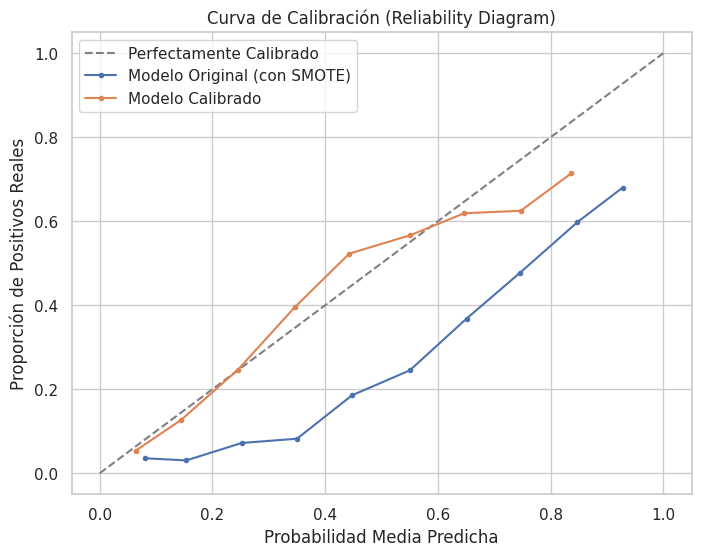

In [ ]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
import matplotlib.pyplot as plt

# 1. Instanciar el Calibrador usando el mejor modelo del GridSearch
# Usamos cv='prefit' porque el best_model ya fue entrenado por GridSearchCV (gracias al refit=True)
calibrated_model = CalibratedClassifierCV(estimator=best_model, method='sigmoid', cv='prefit')

# 2. Calibrar usando el set de validación o una porción de entrenamiento
# (La calibración necesita datos que el modelo no haya usado para sobreajustarse)
calibrated_model.fit(X_train, y_train)

# 3. Comparar Probabilidades (Antes vs Después)
prob_original = best_model.predict_proba(X_test)[:, 1]
prob_calibrada = calibrated_model.predict_proba(X_test)[:, 1]

# Visualización de la Curva de Calibración
fop_orig, mpv_orig = calibration_curve(y_test, prob_original, n_bins=10)
fop_cal, mpv_cal = calibration_curve(y_test, prob_calibrada, n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectamente Calibrado')
plt.plot(mpv_orig, fop_orig, marker='.', label='Modelo Original (con SMOTE)')
plt.plot(mpv_cal, fop_cal, marker='.', label='Modelo Calibrado')
plt.xlabel('Probabilidad Media Predicha')
plt.ylabel('Proporción de Positivos Reales')
plt.title('Curva de Calibración (Reliability Diagram)')
plt.legend()
plt.show()

In [ ]:
#
# Usamos el modelo calibrado
train_proba_calibrated = calibrated_model.predict_proba(X_train)[:, 1]

# Calculamos las métricas con estas nuevas probabilidades
prec_cal, rec_cal, thresholds_cal = precision_recall_curve(y_train, train_proba_calibrated)
f1_cal = 2 * (prec_cal[:-1] * rec_cal[:-1]) / (prec_cal[:-1] + rec_cal[:-1] + 1e-12)
best_idx_cal = int(np.argmax(f1_cal))

# ESTA ES LA VARIABLE QUE DEBE IR AL BACKEND
best_threshold_calibrated = float(thresholds_cal[best_idx_cal])

print(f"\nNuevo Umbral Óptimo (Modelo Calibrado): {best_threshold_calibrated:.4f}")


Nuevo Umbral Óptimo (Modelo Calibrado): 0.2217


**Razonamiento**:
El código anterior generaba mensajes `FutureWarning` debido al uso obsoleto de `errors='ignore'` en `pd.to_numeric` dentro de la función `to_int_01`. Modificaré esta función para manejar las conversiones de tipos de manera más sólida y explícita, usando `errors='coerce'` y asignaciones booleanas, para eliminar estas advertencias y al mismo tiempo mantener la funcionalidad prevista.


**Razonamiento**:
La función `to_int_01` se actualizó y las canalizaciones del preprocesador se redefinieron. Ahora, procederé a generar el informe de clasificación y visualizaré la matriz de confusión para el conjunto de prueba utilizando el `best_threshold_best_model` determinado anteriormente, según los requisitos de la tarea.



In [ ]:
# Cambiar en el Bloque 2:
# 1. Usar calibrated_model
test_proba_calibrated = calibrated_model.predict_proba(X_test)[:, 1]

# 2. Aplicar el nuevo umbral calibrado
y_pred_final = (test_proba_calibrated >= best_threshold_calibrated).astype(int)

# 3. Reporte y Matriz (el resto del código igual, pero usando estas variables)
print(classification_report(y_test, y_pred_final, digits=4))

              precision    recall  f1-score   support

           0     0.8982    0.7425    0.8129      1592
           1     0.4006    0.6716    0.5018       408

    accuracy                         0.7280      2000
   macro avg     0.6494    0.7070    0.6574      2000
weighted avg     0.7967    0.7280    0.7495      2000




=== REPORTE DE EVALUACIÓN FINAL (TEST) ===
Umbral Calibrado aplicado: 0.2217
---------------------------------------------
              precision    recall  f1-score   support

           0     0.8982    0.7425    0.8129      1592
           1     0.4006    0.6716    0.5018       408

    accuracy                         0.7280      2000
   macro avg     0.6494    0.7070    0.6574      2000
weighted avg     0.7967    0.7280    0.7495      2000



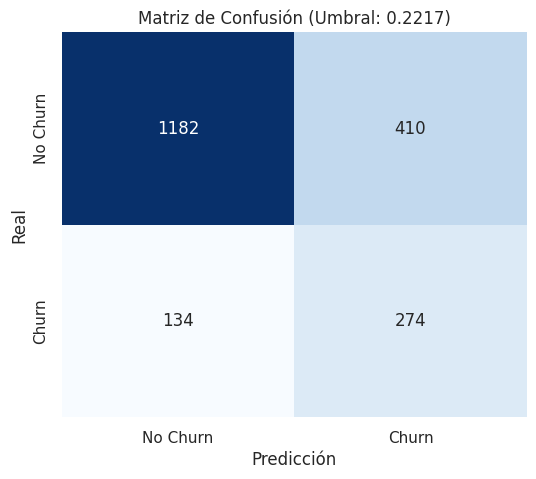

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 9) Evaluación Final: Modelo Calibrado + Umbral Óptimo
# ---------------------------------------------------------

# 1. Generar probabilidades del modelo CALIBRADO y aplicar su umbral
test_proba_calibrated = calibrated_model.predict_proba(X_test)[:, 1]
y_pred_final = (test_proba_calibrated >= best_threshold_calibrated).astype(int)

# 2. Imprimir Reporte de Clasificación (¡Muy importante para ver el F1-Score!)
print(f"\n=== REPORTE DE EVALUACIÓN FINAL (TEST) ===")
print(f"Umbral Calibrado aplicado: {best_threshold_calibrated:.4f}")
print("-" * 45)
print(classification_report(y_test, y_pred_final, digits=4))

# 3. Calcular y visualizar la Matriz de Confusión
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title(f"Matriz de Confusión (Umbral: {best_threshold_calibrated:.4f})")
plt.show()

El panorama completo de esos 2000 datos de prueba:

- 1182 (Verdaderos Negativos): Acierto. Clientes que se quedan y el modelo dijo que se quedarían.

- 274 (Verdaderos Positivos): Acierto. Clientes que se iban y el modelo los detectó.

- 410 (Falsos Positivos): Error. Clientes que se quedan, pero el modelo pensó que se irían. (Aquí es donde el banco "gasta" de más en marketing).

- 134 (Falsos Negativos): Error. Clientes que se van, pero el modelo pensó que se quedarían. (Aquí es donde el banco "pierde" al cliente).

In [ ]:
# Suponiendo que 'calibrated_model' es tu pipeline final entrenado
joblib.dump(calibrated_model, 'churn_model_winner.joblib')

['churn_model_winner.joblib']

In [ ]:
import json
import pandas as pd
import shap
import numpy as np # Necesario para np.abs si no está importado globalmente
import joblib # Para cargar modelos/pipelines

# Las siguientes variables globales (pipeline, _explainer_shap, best_threshold_calibrated,
# NUM_FEATURES, CAT_FEATURES, BIN_FEATURES) se asume que están definidas en celdas previas.

# . Carga del pipeline (entrenado con SMOTE)
pipeline = joblib.load('churn_model_winner.joblib')

# Preparar el background data para SHAP fuera de la función para optimización
_prep_for_shap = pipeline.estimator.named_steps['preprocess']

# Tomar una muestra de X_train para el background data
_X_train_sampled_for_shap = X_train.sample(n=min(len(X_train), 100), random_state=42)
_background_data_for_shap = _prep_for_shap.transform(_X_train_sampled_for_shap)

if hasattr(_background_data_for_shap, 'toarray'):
    _background_data_for_shap = _background_data_for_shap.toarray()
_background_data_df_for_shap = pd.DataFrame(
    _background_data_for_shap,
    columns=_prep_for_shap.get_feature_names_out()
)


# Inicializar el explainer con el background data preparado
_explainer_shap = shap.LinearExplainer(pipeline.estimator.named_steps['model'], _background_data_df_for_shap)


def predict_customer_churn(input_cliente_json):
    """
    Realiza la predicción y genera el JSON con el ranking de importancia SHAP,
    agregando SHAP values para variables categóricas one-hot encoded.
    """
    # Lista de variables que el modelo realmente usa
    VARIABLES_MODELO_ACTUALES = NUM_FEATURES + CAT_FEATURES + BIN_FEATURES

    # Convertir input a DataFrame para el pipeline
    df_input = pd.DataFrame([input_cliente_json])

    # --- A. Inferencia ---
    # Obtenemos la probabilidad del pipeline (clase 1)
    probabilidad = float(pipeline.predict_proba(df_input)[0][1])
    # Usamos tu umbral calibrado (debe estar definido previamente)
    umbral_final = best_threshold_calibrated
    prediccion = 1 if probabilidad >= umbral_final else 0

    # --- B. Preparación SHAP ---
    prep = pipeline.estimator.named_steps['preprocess']
    X_trans = prep.transform(df_input)
    if hasattr(X_trans, 'toarray'):
        X_trans = X_trans.toarray()

    # Nombres de las features después del preprocesamiento
    nombres_features_preprocesadas = prep.get_feature_names_out()

    # Cálculo de SHAP usando el explainer global _explainer_shap
    # shap_values[0] para la clase positiva (churn)
    shap_values_raw = _explainer_shap.shap_values(X_trans)[0]

    # --- C. Construcción del Contrato de Salida (Agregación de SHAP values) ---
    # Diccionario para agregar importancias por nombre de feature original
    aggregated_importances = {}
    # Diccionario para almacenar el valor original de la feature de input
    feature_original_values = {}

    for i, preprocessed_name in enumerate(nombres_features_preprocesadas):
        importance = shap_values_raw[i]
        original_feature = None

        # *** CORRECCIÓN: No hay prefijos num__, bin__, cat__ en nombres_features_preprocesadas ***
        # Identificar la feature original (numérica, binaria o categórica)
        if preprocessed_name in NUM_FEATURES:
            original_feature = preprocessed_name
        elif preprocessed_name in BIN_FEATURES:
            original_feature = preprocessed_name
        else: # Debe ser una característica categórica one-hot encoded
            for cat_name in CAT_FEATURES:
                if preprocessed_name.startswith(f'{cat_name}_'): # Ej: 'Geography_France' empieza con 'Geography_'
                    original_feature = cat_name
                    break

        if original_feature:
            aggregated_importances[original_feature] = \
                aggregated_importances.get(original_feature, 0.0) + importance
            # Solo almacenamos el valor del input una vez por feature original
            if original_feature not in feature_original_values:
                feature_original_values[original_feature] = input_cliente_json.get(original_feature)

    # Construir la lista final de importancias para las features ACTIVAS del modelo
    importancias_final = []
    for f_name, agg_value in aggregated_importances.items():
        importancias_final.append({
            "feature_name": f_name,
            "feature_value": feature_original_values.get(f_name), # Usar el valor original del input
            "importance_value": float(agg_value) # Mantener como float para sorting, redondear al final
        })

    # 2. Agregar variables que fueron enviadas pero desechadas por el modelo
    for col in input_cliente_json.keys():
        if col not in VARIABLES_MODELO_ACTUALES:
            importancias_final.append({
                "feature_name": col,
                "feature_value": input_cliente_json[col],
                "importance_value": 0.0,
                "note": "Variable no utilizada en el entrenamiento"
            })

    # 3. Ordenar por Impacto Absoluto (Ranking)
    # Ordena primero si la nota 'Variable no utilizada...' existe (False para usadas, True para no usadas)
    # Luego, dentro de cada grupo, ordena por el valor absoluto de la importancia de forma descendente.

    importancias_ordenadas = sorted(
        importancias_final,
        key=lambda x: (x.get('note') == 'Variable no utilizada en el entrenamiento', -abs(x["importance_value"]))
    )

    # Asignar el número de ranking y redondear importance_value
    for index, item in enumerate(importancias_ordenadas):

        item["ranking"] = index + 1
        item["importance_value"] = round(item["importance_value"], 4) # Redondeo


    # --- D. Resultado Final ---
    return {
        "forecast": int(prediccion),
        "probability": round(probabilidad, 4),
        "feature_importances": importancias_ordenadas
    }


In [ ]:
# 1. Preparación del Input del 1er Cliente
input_cliente_json = {
    "CreditScore": 600,
    "Geography": "Spain",
    "Gender": "Male",
    "Age": 45,
    "Tenure": 3,
    "Balance": 50000.00,
    "NumOfProducts": 2,
    "HasCrCard": 1,
    "IsActiveMember": 0,
    "EstimatedSalary": 40000.00,
    "Complain": 1,
    "SatisfactionScore": 4,
    "CardType": "GOLD",
    "PointEarned": 500
}

# 2. Llamada a la función unificada
reporte_cliente_shap = predict_customer_churn(input_cliente_json)

# 3. Impresión del Reporte Final
print("\n--- Contrato de Salida) ---")
print(json.dumps(reporte_cliente_shap, indent=4))


--- Contrato de Salida) ---
{
    "forecast": 1,
    "probability": 0.2261,
    "feature_importances": [
        {
            "feature_name": "Age",
            "feature_value": 45,
            "importance_value": 0.4564,
            "ranking": 1
        },
        {
            "feature_name": "IsActiveMember",
            "feature_value": 0,
            "importance_value": 0.4483,
            "ranking": 2
        },
        {
            "feature_name": "Gender",
            "feature_value": "Male",
            "importance_value": -0.2303,
            "ranking": 3
        },
        {
            "feature_name": "Geography",
            "feature_value": "Spain",
            "importance_value": -0.132,
            "ranking": 4
        },
        {
            "feature_name": "Balance",
            "feature_value": 50000.0,
            "importance_value": -0.0682,
            "ranking": 5
        },
        {
            "feature_name": "CreditScore",
            "feature_value": 600

In [ ]:
# 1. Preparación del Input del Cliente para el segundo ejemplo
input2_cliente_json = {
    "CreditScore": 550,
    "Geography": "France",
    "Gender": "Male",
    "Age": 60,
    "Tenure": 1,
    "Balance": 25000.00,
    "NumOfProducts": 2,
    "HasCrCard": 0,
    "IsActiveMember": 0,
    "EstimatedSalary": 20000.00,
    "Complain": 0,
    "SatisfactionScore": 2,
    "CardType": "PLATINUM",
    "PointEarned": 200
}

# 2. Llamada a la función unificada para el tercer cliente
reporte2_cliente_shap = predict_customer_churn(input2_cliente_json)

# 3. Impresión del Reporte Final para el tercer cliente
print("\n--- Contrato de Salida) ---")
print(json.dumps(reporte2_cliente_shap, indent=4))


--- Contrato de Salida) ---
{
    "forecast": 1,
    "probability": 0.4624,
    "feature_importances": [
        {
            "feature_name": "Age",
            "feature_value": 60,
            "importance_value": 1.5805,
            "ranking": 1
        },
        {
            "feature_name": "IsActiveMember",
            "feature_value": 0,
            "importance_value": 0.4483,
            "ranking": 2
        },
        {
            "feature_name": "Gender",
            "feature_value": "Male",
            "importance_value": -0.2303,
            "ranking": 3
        },
        {
            "feature_name": "Geography",
            "feature_value": "France",
            "importance_value": -0.157,
            "ranking": 4
        },
        {
            "feature_name": "Balance",
            "feature_value": 25000.0,
            "importance_value": -0.1348,
            "ranking": 5
        },
        {
            "feature_name": "CreditScore",
            "feature_value": 55

In [ ]:
# 1. Preparación del Input del Cliente para el tercer ejemplo
input3_cliente_json = {
    "CreditScore": 550,
    "Geography": "Spain",
    "Gender": "Female",
    "Age": 20,
    "Tenure": 1,
    "Balance": 25000.00,
    "NumOfProducts": 2,
    "HasCrCard": 0,
    "IsActiveMember": 0,
    "EstimatedSalary": 35000.00,
    "Complain": 0,
    "SatisfactionScore": 2,
    "CardType": "PLATINUM",
    "PointEarned": 200
}

# 2. Llamada a la función unificada para el tercer cliente
reporte3_cliente_shap = predict_customer_churn(input3_cliente_json)

# 3. Impresión del Reporte Final para el tercer cliente
print("\n--- Contrato de Salida) ---")
print(json.dumps(reporte3_cliente_shap, indent=3))


--- Contrato de Salida) ---
{
   "forecast": 0,
   "probability": 0.0699,
   "feature_importances": [
      {
         "feature_name": "Age",
         "feature_value": 20,
         "importance_value": -1.4171,
         "ranking": 1
      },
      {
         "feature_name": "IsActiveMember",
         "feature_value": 0,
         "importance_value": 0.4483,
         "ranking": 2
      },
      {
         "feature_name": "Gender",
         "feature_value": "Female",
         "importance_value": 0.2931,
         "ranking": 3
      },
      {
         "feature_name": "Balance",
         "feature_value": 25000.0,
         "importance_value": -0.1348,
         "ranking": 4
      },
      {
         "feature_name": "Geography",
         "feature_value": "Spain",
         "importance_value": -0.132,
         "ranking": 5
      },
      {
         "feature_name": "CreditScore",
         "feature_value": 550,
         "importance_value": 0.1148,
         "ranking": 6
      },
      {
         "f

In [ ]:

# Ejemplo 4
input4_cliente_json = {
    "CreditScore": 600,
    "Geography": "France",
    "Gender": "Male",
    "Age": 40,
    "Tenure": 3,
    "Balance": 50000.00,
    "NumOfProducts": 1,
    "HasCrCard": 1,
    "IsActiveMember": 1,
    "EstimatedSalary": 60000.00,
    "Complain": 0,
    "SatisfactionScore": 4,
    "CardType": "GOLD",
    "PointEarned": 500
}

# 2. Llamada a la función unificada para el tercer cliente
reporte4_cliente_shap = predict_customer_churn(input4_cliente_json)

# 3. Impresión del Reporte Final para el tercer cliente
print("\n--- Contrato de Salida v4 ---")
print(json.dumps(reporte4_cliente_shap, indent=4))


--- Contrato de Salida v4 ---
{
    "forecast": 0,
    "probability": 0.09,
    "feature_importances": [
        {
            "feature_name": "IsActiveMember",
            "feature_value": 1,
            "importance_value": -0.3382,
            "ranking": 1
        },
        {
            "feature_name": "Gender",
            "feature_value": "Male",
            "importance_value": -0.2303,
            "ranking": 2
        },
        {
            "feature_name": "Geography",
            "feature_value": "France",
            "importance_value": -0.157,
            "ranking": 3
        },
        {
            "feature_name": "Age",
            "feature_value": 40,
            "importance_value": 0.0817,
            "ranking": 4
        },
        {
            "feature_name": "Balance",
            "feature_value": 50000.0,
            "importance_value": -0.0682,
            "ranking": 5
        },
        {
            "feature_name": "CreditScore",
            "feature_value": 6

In [ ]:
import joblib

# 1. Definir los nombres de los archivos
archivo_modelo = 'churn_model_winner.joblib'
archivo_metadata = 'metadata_modelo.joblib'

# 2. Guardar el Pipeline (Modelo + Preprocesamiento) - AHORA ES EL CALIBRADO
joblib.dump(calibrated_model, archivo_modelo)

# 3. Guardar los Metadatos (Umbral y métricas)
metadata = {
    'umbral_optimo': best_threshold_calibrated

}
joblib.dump(metadata, archivo_metadata)

print(f"✅ Proceso completado:")
print(f"- Modelo guardado en: {archivo_modelo}")
print(f"- Umbral ({best_threshold_calibrated:.4f}) guardado en: {archivo_metadata}")

✅ Proceso completado:
- Modelo guardado en: churn_model_winner.joblib
- Umbral (0.2217) guardado en: metadata_modelo.joblib
